In [1]:
import gymnasium as gym

_tmp_env = gym.make("CartPole-v1")
print("Observation Space:", _tmp_env.observation_space)
print("Action Space     :", _tmp_env.action_space)
_tmp_env.close()


Observation Space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action Space     : Discrete(2)


In [2]:
%%capture
!pip install -q gymnasium torch numpy matplotlib imageio imageio-ffmpeg tqdm
!pip install -q "gymnasium[classic-control]"


In [3]:
print("✅ Dependencies installed successfully.")


✅ Dependencies installed successfully.


In [4]:
import os
import json
import random
import shutil
from collections import deque, namedtuple
from dataclasses import dataclass, asdict
from datetime import datetime
from typing import List, Tuple, Deque, Optional

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm.auto import tqdm
import imageio

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("Libraries imported successfully.")
print(f"Running in Google Colab: {IN_COLAB}")


Libraries imported successfully.
Running in Google Colab: True


In [5]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Selected device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")


Selected device: cuda
GPU Name: Tesla T4


In [6]:
SEED: int = 42

def set_global_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_global_seed(SEED)
print(f"Global random seed set to {SEED}.")


Global random seed set to 42.


In [7]:
ENV_ID: str = "CartPole-v1"

env = gym.make(ENV_ID)
env.reset(seed=SEED)

STATE_DIM: int = env.observation_space.shape[0]
ACTION_DIM: int = env.action_space.n
MAX_EPISODE_STEPS: int = env.spec.max_episode_steps

print(f"Environment           : {ENV_ID}")
print(f"Observation Space     : {env.observation_space}  (state_dim={STATE_DIM})")
print(f"Action Space          : {env.action_space}  (action_dim={ACTION_DIM})")
print(f"Max Episode Steps     : {MAX_EPISODE_STEPS}")


Environment           : CartPole-v1
Observation Space     : Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)  (state_dim=4)
Action Space          : Discrete(2)  (action_dim=2)
Max Episode Steps     : 500


In [8]:
def run_random_agent(env: gym.Env, n_episodes: int = 5) -> List[float]:
    episode_rewards = []
    for episode in range(1, n_episodes + 1):
        state, _ = env.reset()
        total_reward = 0.0
        done = False
        while not done:
            action = env.action_space.sample()
            state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            done = terminated or truncated
        episode_rewards.append(total_reward)
        print(f"Random Agent | Episode {episode:>2} | Reward: {total_reward:.1f}")
    return episode_rewards

random_rewards = run_random_agent(env, n_episodes=5)
print(f"\nAverage reward over {len(random_rewards)} random episodes: {np.mean(random_rewards):.2f}")


Random Agent | Episode  1 | Reward: 11.0
Random Agent | Episode  2 | Reward: 26.0
Random Agent | Episode  3 | Reward: 15.0
Random Agent | Episode  4 | Reward: 16.0
Random Agent | Episode  5 | Reward: 20.0

Average reward over 5 random episodes: 17.60


In [9]:
Transition = namedtuple(
    "Transition", ("state", "action", "reward", "next_state", "done")
)


class ReplayBuffer:
    def __init__(self, capacity: int) -> None:
        self.buffer: Deque[Transition] = deque(maxlen=capacity)

    def push(
        self,
        state: np.ndarray,
        action: int,
        reward: float,
        next_state: np.ndarray,
        done: bool,
    ) -> None:
        self.buffer.append(Transition(state, action, reward, next_state, done))

    def sample(self, batch_size: int) -> Transition:
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return Transition(
            np.array(states, dtype=np.float32),
            np.array(actions, dtype=np.int64),
            np.array(rewards, dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones, dtype=np.float32),
        )

    def __len__(self) -> int:
        return len(self.buffer)


In [10]:
class DQNNetwork(nn.Module):
    def __init__(self, state_dim: int, action_dim: int, hidden_size: int = 128) -> None:
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, action_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


In [11]:
@dataclass
class DQNConfig:
    num_episodes: int = 500
    gamma: float = 0.99
    learning_rate: float = 5e-4
    batch_size: int = 64
    buffer_capacity: int = 10_000
    min_buffer_size: int = 1_000
    epsilon_start: float = 1.0
    epsilon_end: float = 0.01
    epsilon_decay: float = 0.995
    use_double_dqn: bool = True
    tau: float = 0.005
    hidden_size: int = 128
    max_steps_per_episode: int = 500
    grad_clip_norm: float = 10.0
    seed: int = SEED

config = DQNConfig()
print(json.dumps(asdict(config), indent=2))


{
  "num_episodes": 500,
  "gamma": 0.99,
  "learning_rate": 0.0005,
  "batch_size": 64,
  "buffer_capacity": 10000,
  "min_buffer_size": 1000,
  "epsilon_start": 1.0,
  "epsilon_end": 0.01,
  "epsilon_decay": 0.995,
  "use_double_dqn": true,
  "tau": 0.005,
  "hidden_size": 128,
  "max_steps_per_episode": 500,
  "grad_clip_norm": 10.0,
  "seed": 42
}


In [12]:
OUTPUT_DIRS = ["models", "plots", "videos", "logs", "exports"]
for d in OUTPUT_DIRS:
    os.makedirs(d, exist_ok=True)
print("Created/verified folders:", OUTPUT_DIRS)


Created/verified folders: ['models', 'plots', 'videos', 'logs', 'exports']


In [13]:
class DQNAgent:
    def __init__(self, state_dim: int, action_dim: int, config: DQNConfig, device: torch.device) -> None:
        self.config = config
        self.device = device
        self.action_dim = action_dim

        self.online_net = DQNNetwork(state_dim, action_dim, config.hidden_size).to(device)
        self.target_net = DQNNetwork(state_dim, action_dim, config.hidden_size).to(device)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.online_net.parameters(), lr=config.learning_rate)
        self.replay_buffer = ReplayBuffer(config.buffer_capacity)
        self.epsilon = config.epsilon_start

    def select_action(self, state: np.ndarray) -> int:
        if random.random() < self.epsilon:
            return random.randrange(self.action_dim)
        with torch.no_grad():
            state_t = torch.as_tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
            q_values = self.online_net(state_t)
            return int(torch.argmax(q_values, dim=1).item())

    def decay_epsilon(self) -> None:
        self.epsilon = max(self.config.epsilon_end, self.epsilon * self.config.epsilon_decay)

    def soft_update_target(self) -> None:
        tau = self.config.tau
        for target_param, online_param in zip(
            self.target_net.parameters(), self.online_net.parameters()
        ):
            target_param.data.copy_(tau * online_param.data + (1.0 - tau) * target_param.data)

    def learn(self) -> Optional[float]:
        if len(self.replay_buffer) < self.config.min_buffer_size:
            return None

        batch = self.replay_buffer.sample(self.config.batch_size)
        states = torch.as_tensor(batch.state, device=self.device)
        actions = torch.as_tensor(batch.action, device=self.device).unsqueeze(1)
        rewards = torch.as_tensor(batch.reward, device=self.device)
        next_states = torch.as_tensor(batch.next_state, device=self.device)
        dones = torch.as_tensor(batch.done, device=self.device)

        q_values = self.online_net(states).gather(1, actions).squeeze(1)

        with torch.no_grad():
            if self.config.use_double_dqn:
                next_actions = self.online_net(next_states).argmax(dim=1, keepdim=True)
                next_q_values = self.target_net(next_states).gather(1, next_actions).squeeze(1)
            else:
                next_q_values = self.target_net(next_states).max(dim=1)[0]
            targets = rewards + self.config.gamma * next_q_values * (1.0 - dones)

        loss = F.smooth_l1_loss(q_values, targets)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.online_net.parameters(), self.config.grad_clip_norm)
        self.optimizer.step()

        self.soft_update_target()

        return float(loss.item())


In [14]:
def train_dqn(
    env: gym.Env,
    agent: DQNAgent,
    config: DQNConfig,
    models_dir: str = "models",
    logs_dir: str = "logs",
) -> Tuple[List[float], List[float], List[float]]:
    episode_rewards: List[float] = []
    episode_losses: List[float] = []
    epsilon_history: List[float] = []
    best_reward = -float("inf")
    best_model_path = os.path.join(models_dir, "dqn_cartpole_best.pth")

    progress_bar = tqdm(range(1, config.num_episodes + 1), desc="Training DQN")
    for episode in progress_bar:
        state, _ = env.reset()
        total_reward = 0.0
        losses_this_episode: List[float] = []

        for _step in range(config.max_steps_per_episode):
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            agent.replay_buffer.push(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward

            loss = agent.learn()
            if loss is not None:
                losses_this_episode.append(loss)

            if done:
                break

        agent.decay_epsilon()

        avg_loss = float(np.mean(losses_this_episode)) if losses_this_episode else 0.0
        episode_rewards.append(total_reward)
        episode_losses.append(avg_loss)
        epsilon_history.append(agent.epsilon)

        if total_reward > best_reward:
            best_reward = total_reward
            torch.save(
                {
                    "model_state_dict": agent.online_net.state_dict(),
                    "episode": episode,
                    "reward": best_reward,
                    "config": asdict(config),
                },
                best_model_path,
            )

        progress_bar.set_postfix(
            reward=f"{total_reward:.0f}", best=f"{best_reward:.0f}", eps=f"{agent.epsilon:.3f}"
        )

        if episode % 20 == 0:
            recent_avg = float(np.mean(episode_rewards[-20:]))
            print(
                f"Episode {episode:>4}/{config.num_episodes} | "
                f"Reward: {total_reward:>5.0f} | "
                f"Avg(last 20): {recent_avg:>6.1f} | "
                f"Epsilon: {agent.epsilon:.3f} | "
                f"Best: {best_reward:.0f}"
            )

    log_path = os.path.join(logs_dir, "training_log.csv")
    with open(log_path, "w") as f:
        f.write("episode,reward,avg_loss,epsilon\n")
        for i, (r, l, e) in enumerate(zip(episode_rewards, episode_losses, epsilon_history), start=1):
            f.write(f"{i},{r},{l},{e}\n")

    print(f"\n✅ Training complete. Best reward achieved: {best_reward:.0f}")
    print(f"✅ Best model saved to: {best_model_path}")
    print(f"✅ Training log saved to: {log_path}")

    return episode_rewards, episode_losses, epsilon_history


In [15]:
agent = DQNAgent(STATE_DIM, ACTION_DIM, config, DEVICE)

episode_rewards, episode_losses, epsilon_history = train_dqn(
    env=env, agent=agent, config=config, models_dir="models", logs_dir="logs"
)


Training DQN:   0%|          | 0/500 [00:00<?, ?it/s]

Episode   20/500 | Reward:    17 | Avg(last 20):   21.6 | Epsilon: 0.905 | Best: 68
Episode   40/500 | Reward:    15 | Avg(last 20):   22.8 | Epsilon: 0.818 | Best: 68
Episode   60/500 | Reward:    17 | Avg(last 20):   20.7 | Epsilon: 0.740 | Best: 68
Episode   80/500 | Reward:    67 | Avg(last 20):   24.0 | Epsilon: 0.670 | Best: 68
Episode  100/500 | Reward:    59 | Avg(last 20):   56.2 | Epsilon: 0.606 | Best: 159
Episode  120/500 | Reward:    52 | Avg(last 20):   71.7 | Epsilon: 0.548 | Best: 269
Episode  140/500 | Reward:    18 | Avg(last 20):   55.1 | Epsilon: 0.496 | Best: 269
Episode  160/500 | Reward:    16 | Avg(last 20):  108.8 | Epsilon: 0.448 | Best: 283
Episode  180/500 | Reward:   211 | Avg(last 20):   88.1 | Epsilon: 0.406 | Best: 318
Episode  200/500 | Reward:   180 | Avg(last 20):  117.8 | Epsilon: 0.367 | Best: 348
Episode  220/500 | Reward:   203 | Avg(last 20):  131.8 | Epsilon: 0.332 | Best: 371
Episode  240/500 | Reward:    16 | Avg(last 20):   79.2 | Epsilon: 0.

In [16]:
BEST_MODEL_PATH = os.path.join("models", "dqn_cartpole_best.pth")
checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE)

print(f"Checkpoint file       : {BEST_MODEL_PATH}")
print(f"Achieved at episode   : {checkpoint['episode']}")
print(f"Best episode reward   : {checkpoint['reward']}")
print(f"File size (KB)        : {os.path.getsize(BEST_MODEL_PATH) / 1024:.1f}")


Checkpoint file       : models/dqn_cartpole_best.pth
Achieved at episode   : 210
Best episode reward   : 371.0
File size (KB)        : 71.5


In [17]:
def load_agent_for_eval(model_path: str, state_dim: int, action_dim: int, config: DQNConfig, device: torch.device) -> DQNNetwork:
    net = DQNNetwork(state_dim, action_dim, config.hidden_size).to(device)
    ckpt = torch.load(model_path, map_location=device)
    net.load_state_dict(ckpt["model_state_dict"])
    net.eval()
    return net


def evaluate_agent(
    env: gym.Env, net: DQNNetwork, device: torch.device, n_episodes: int = 20
) -> List[float]:
    rewards = []
    for episode in range(1, n_episodes + 1):
        state, _ = env.reset()
        total_reward = 0.0
        done = False
        while not done:
            with torch.no_grad():
                state_t = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
                action = int(torch.argmax(net(state_t), dim=1).item())
            state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            done = terminated or truncated
        rewards.append(total_reward)
    return rewards


eval_net = load_agent_for_eval(BEST_MODEL_PATH, STATE_DIM, ACTION_DIM, config, DEVICE)
eval_rewards = evaluate_agent(env, eval_net, DEVICE, n_episodes=20)

eval_stats = {
    "average_reward": float(np.mean(eval_rewards)),
    "max_reward": float(np.max(eval_rewards)),
    "min_reward": float(np.min(eval_rewards)),
    "std_reward": float(np.std(eval_rewards)),
    "n_episodes": len(eval_rewards),
}

print("📊 Evaluation Results (greedy policy, 20 episodes)")
print("-" * 45)
for key, value in eval_stats.items():
    print(f"{key:>16}: {value:.3f}" if isinstance(value, float) else f"{key:>16}: {value}")


📊 Evaluation Results (greedy policy, 20 episodes)
---------------------------------------------
  average_reward: 380.200
      max_reward: 500.000
      min_reward: 263.000
      std_reward: 80.772
      n_episodes: 20


In [18]:
def record_gameplay_video(
    net: DQNNetwork,
    device: torch.device,
    env_id: str,
    video_path: str,
    max_steps: int = 500,
    fps: int = 30,
) -> float:
    render_env = gym.make(env_id, render_mode="rgb_array")
    state, _ = render_env.reset(seed=SEED)
    frames = []
    total_reward = 0.0

    for _ in range(max_steps):
        frames.append(render_env.render())
        with torch.no_grad():
            state_t = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            action = int(torch.argmax(net(state_t), dim=1).item())
        state, reward, terminated, truncated, _ = render_env.step(action)
        total_reward += reward
        if terminated or truncated:
            break

    render_env.close()
    imageio.mimsave(video_path, frames, fps=fps)
    return total_reward


VIDEO_PATH = os.path.join("videos", "dqn_cartpole_gameplay.mp4")
video_reward = record_gameplay_video(eval_net, DEVICE, ENV_ID, VIDEO_PATH)
print(f"🎥 Recorded gameplay episode with total reward: {video_reward:.0f}")
print(f"Saved to: {VIDEO_PATH}")


🎥 Recorded gameplay episode with total reward: 399
Saved to: videos/dqn_cartpole_gameplay.mp4


In [19]:
from IPython.display import Video, display

display(Video(VIDEO_PATH, embed=True, width=480))


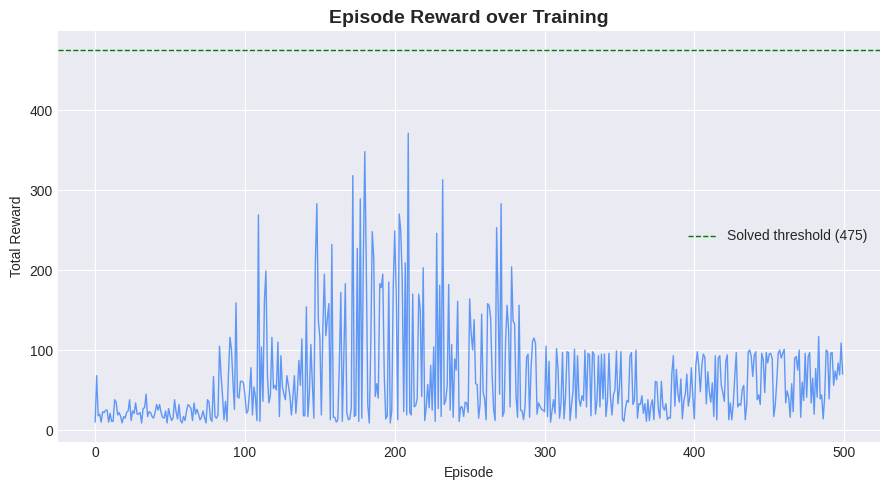

In [20]:
def moving_average(values: List[float], window: int = 20) -> np.ndarray:
    values = np.asarray(values, dtype=np.float32)
    if len(values) < window:
        return values
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")


plt.style.use("seaborn-v0_8-darkgrid") if "seaborn-v0_8-darkgrid" in plt.style.available else None

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(episode_rewards, color="#3b82f6", linewidth=1, alpha=0.8)
ax.set_title("Episode Reward over Training", fontsize=14, fontweight="bold")
ax.set_xlabel("Episode")
ax.set_ylabel("Total Reward")
ax.axhline(475, color="green", linestyle="--", linewidth=1, label="Solved threshold (475)")
ax.legend()
fig.tight_layout()
fig.savefig("plots/episode_reward.png", dpi=150)
plt.show()


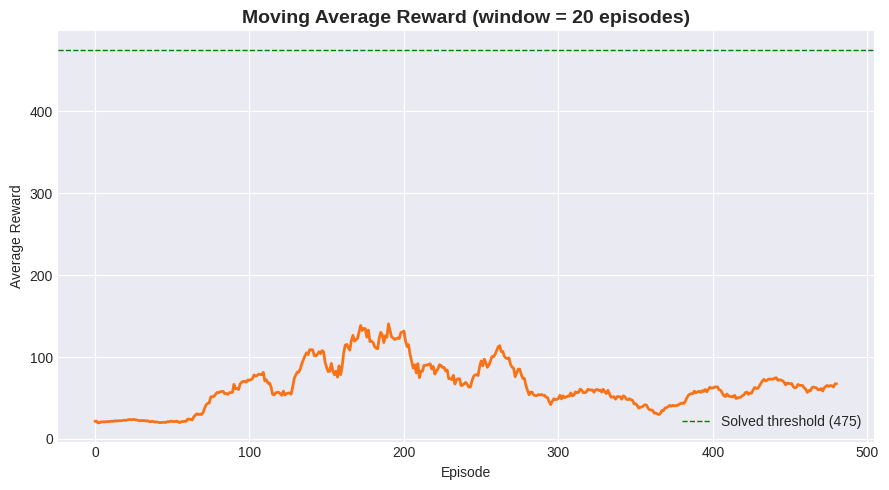

In [21]:
ma_rewards = moving_average(episode_rewards, window=20)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(len(ma_rewards)), ma_rewards, color="#f97316", linewidth=2)
ax.set_title("Moving Average Reward (window = 20 episodes)", fontsize=14, fontweight="bold")
ax.set_xlabel("Episode")
ax.set_ylabel("Average Reward")
ax.axhline(475, color="green", linestyle="--", linewidth=1, label="Solved threshold (475)")
ax.legend()
fig.tight_layout()
fig.savefig("plots/moving_average_reward.png", dpi=150)
plt.show()


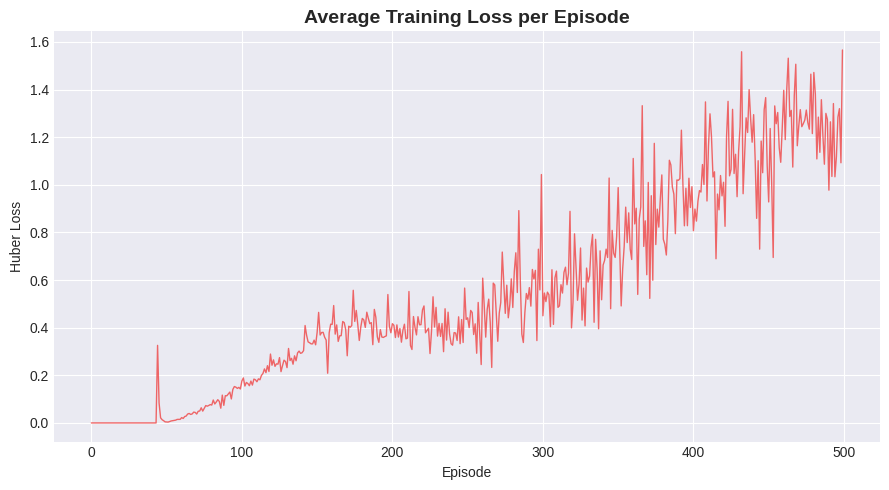

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(episode_losses, color="#ef4444", linewidth=1, alpha=0.8)
ax.set_title("Average Training Loss per Episode", fontsize=14, fontweight="bold")
ax.set_xlabel("Episode")
ax.set_ylabel("Huber Loss")
fig.tight_layout()
fig.savefig("plots/training_loss.png", dpi=150)
plt.show()


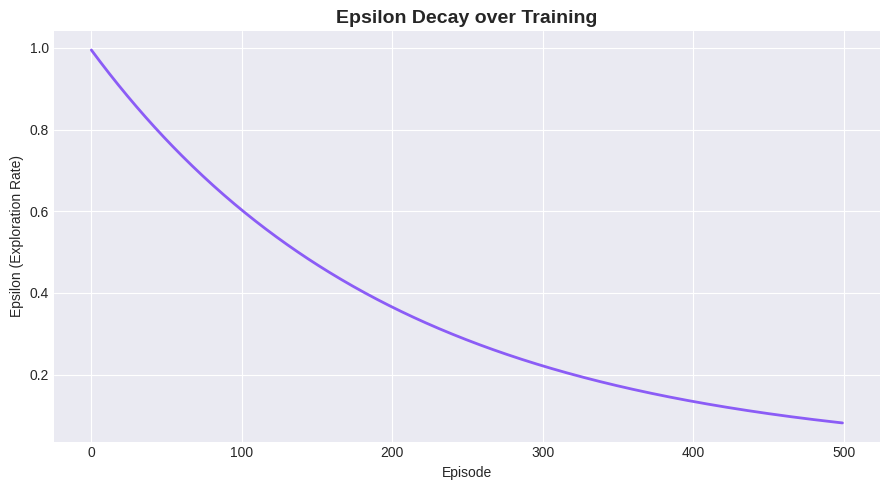

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(epsilon_history, color="#8b5cf6", linewidth=2)
ax.set_title("Epsilon Decay over Training", fontsize=14, fontweight="bold")
ax.set_xlabel("Episode")
ax.set_ylabel("Epsilon (Exploration Rate)")
fig.tight_layout()
fig.savefig("plots/epsilon_decay.png", dpi=150)
plt.show()


In [24]:
def generate_discussion(
    episode_rewards: List[float], eval_stats: dict, config: DQNConfig
) -> str:
    first_20_avg = float(np.mean(episode_rewards[:20]))
    last_20_avg = float(np.mean(episode_rewards[-20:]))
    improvement = last_20_avg - first_20_avg
    solved = eval_stats["average_reward"] >= 475

    lines = [
        f"- **Training trend:** Average reward over the first 20 episodes was "
        f"{first_20_avg:.1f}, compared to {last_20_avg:.1f} over the final 20 episodes "
        f"(a change of {improvement:+.1f}), indicating the agent {'clearly learned an improved policy' if improvement > 50 else 'showed some learning progress' if improvement > 0 else 'did not show a clear net improvement'} over training.",
        f"- **Convergence:** The moving-average reward curve "
        f"{'plateaus near the maximum achievable reward' if last_20_avg > 400 else 'is still trending upward toward higher rewards' if last_20_avg > first_20_avg else 'has not yet converged toward the solved threshold'}, "
        f"suggesting {'the policy has largely converged' if last_20_avg > 400 else 'additional training episodes, or further hyperparameter tuning, may be needed'}.",
        f"- **Performance:** Greedy-policy evaluation over {eval_stats['n_episodes']} episodes yielded "
        f"an average reward of {eval_stats['average_reward']:.1f} (min={eval_stats['min_reward']:.0f}, "
        f"max={eval_stats['max_reward']:.0f}, std={eval_stats['std_reward']:.1f}). "
        f"{'This meets the classic solved threshold of 475.' if solved else 'This is below the classic solved threshold of 475, suggesting further tuning or training would help.'}",
        "- **Limitations:** Even with Double DQN and soft target updates, value-based methods "
        "offer no formal convergence guarantee under function approximation, remain sensitive to "
        "hyperparameters (learning rate, tau, epsilon schedule), and can still show run-to-run "
        "reward variance due to CartPole's chaotic dynamics.",
    ]
    return "\n".join(lines)


discussion_text = generate_discussion(episode_rewards, eval_stats, config)
print(discussion_text)


- **Training trend:** Average reward over the first 20 episodes was 21.6, compared to 67.4 over the final 20 episodes (a change of +45.9), indicating the agent showed some learning progress over training.
- **Convergence:** The moving-average reward curve is still trending upward toward higher rewards, suggesting additional training episodes, or further hyperparameter tuning, may be needed.
- **Performance:** Greedy-policy evaluation over 20 episodes yielded an average reward of 380.2 (min=263, max=500, std=80.8). This is below the classic solved threshold of 475, suggesting further tuning or training would help.
- **Limitations:** Even with Double DQN and soft target updates, value-based methods offer no formal convergence guarantee under function approximation, remain sensitive to hyperparameters (learning rate, tau, epsilon schedule), and can still show run-to-run reward variance due to CartPole's chaotic dynamics.


In [25]:
config_export_path = os.path.join("exports", "hyperparameters.json")
with open(config_export_path, "w") as f:
    json.dump(asdict(config), f, indent=2)

eval_export_path = os.path.join("exports", "evaluation_stats.json")
with open(eval_export_path, "w") as f:
    json.dump(eval_stats, f, indent=2)

stats_csv_path = os.path.join("logs", "training_statistics.csv")
with open(stats_csv_path, "w") as f:
    f.write("episode,reward,avg_loss,epsilon\n")
    for i, (r, l, e) in enumerate(zip(episode_rewards, episode_losses, epsilon_history), start=1):
        f.write(f"{i},{r},{l},{e}\n")

summary_export_path = os.path.join("exports", "run_summary.txt")
with open(summary_export_path, "w") as f:
    f.write(f"Run timestamp: {datetime.now().isoformat()}\n\n")
    f.write(discussion_text + "\n")

print("Exported:")
for p in [config_export_path, eval_export_path, stats_csv_path, summary_export_path]:
    print(" -", p)


Exported:
 - exports/hyperparameters.json
 - exports/evaluation_stats.json
 - logs/training_statistics.csv
 - exports/run_summary.txt


In [26]:
ZIP_BASENAME = "dqn_cartpole_outputs"
STAGING_DIR = "_export_staging"

if os.path.exists(STAGING_DIR):
    shutil.rmtree(STAGING_DIR)
os.makedirs(STAGING_DIR)
for d in OUTPUT_DIRS:
    shutil.copytree(d, os.path.join(STAGING_DIR, d))

zip_path_no_ext = os.path.abspath(ZIP_BASENAME)
zip_path = shutil.make_archive(zip_path_no_ext, "zip", root_dir=STAGING_DIR)
shutil.rmtree(STAGING_DIR)

print(f"📦 Created archive: {zip_path} ({os.path.getsize(zip_path) / 1024:.1f} KB)")


📦 Created archive: /content/dqn_cartpole_outputs.zip (436.4 KB)


In [27]:
def download_file_if_colab(path: str) -> None:
    if not IN_COLAB:
        return
    if not os.path.exists(path):
        print(f"⚠️  Skipping download — file not found: {path}")
        return
    from google.colab import files as colab_files
    colab_files.download(path)


files_to_download = [
    BEST_MODEL_PATH,
    "plots/episode_reward.png",
    "plots/training_loss.png",
    "plots/epsilon_decay.png",
    "plots/moving_average_reward.png",
    VIDEO_PATH,
    config_export_path,
    stats_csv_path,
]

if IN_COLAB:
    print("📥 Running in Google Colab — triggering automatic downloads...")
    for fp in files_to_download:
        download_file_if_colab(fp)
    download_file_if_colab(zip_path)
    print("✅ All individual files and the full ZIP archive have been sent to your browser downloads.")
else:
    print("ℹ️  Not running in Google Colab — skipping auto-download.")
    print("   All artifacts remain available locally in:", ", ".join(OUTPUT_DIRS))
    print(f"   Combined archive available at: {zip_path}")


📥 Running in Google Colab — triggering automatic downloads...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All individual files and the full ZIP archive have been sent to your browser downloads.
